<a href="https://colab.research.google.com/github/sruthirams163/Modelling-a-neutron-star/blob/main/Modelling_a_neutron_star.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling of Neutron Star using Numerical Method



In [ ]:
#importing libraries
import numpy as np
import matplotlib.pyplot as plt

#### **Initial number densisty of a neutron star**

-  Initial number of neutrons per unit volume at r = 0
- The equation is in the form of a nonlinear algebraic equation and cannot be solved analytically. Therefore, the Newton-Raphson method is used to iteratively find the value of "n" that satisfies the equation.

**Equation to be used in Newton Raphson Method:-**      
$f(n) = {236.n^{2.54} + n.m_n - \rho_s}$       
$f'(n) = 236 \times 2.54 \times n^{1.54} + m_n$

**Newton Raphson Method:-**          
$n_{i+1} = n_i - \frac{f(n_i)}{f'(n_i)}$

In [ ]:
def initial_n():

    n = 1                                   # Initial value of n
    err = 1                                 # Inital Error
    tol = 1e-15                             # Tolerance Value
    count = 0                               # To track total iterations for convergence

    # Newton-Raphson method
    while err > tol :                       # Untill convergence of n
        count += 1                          # Increment the count of the iteration
        fn = 236*n**(2.54) + n*mn - rho_s   # Find f(n_old)
        dfn = 236*2.54*n**(1.54) + mn       # Find f'(n_old)
        temp = n - fn/dfn                   # Calculate n_new using Newton Raphson Method
        err = np.abs(n-temp)                # Calculate the error
        n = temp                            # Use this n value in next iteration for f(n_old), f'(n_old)
    print("Newton-Raphson Converged after ", count, "iterations")
    return n

 **Energy density $ρ$ of the neutron star given the pressure**
- This function will be used to calculate the energy density (ρ) of the neutron star given the pressure (p) at a particular point. It uses the TOV equation to determine the relationship between pressure and energy density.

- The first step in the function is to calculate the number density (n) of the neutron star using the input pressure (p) and the known values of the neutron mass (mn) and the nuclear central density ($\rho_s$). The equation used for this is:

- $n = (\frac{p.\rho_s}{363.44})^{(1/2.54)}$

- Once the number density is known, the energy density can be calculated using the TOV equation:

- ${\rho(p) = \frac{236.n^{2.54} + n.m_n}{\rho_s}}$

This equation relates the energy density ($\rho$) to the number density (n) and neutron mass (mn). The function then returns the calculated energy density.

In [ ]:
def rho(p):

    n = (p*rho_s/363.44)**(1/2.54)
    return (236. * n**2.54 + n *mn)/rho_s

#### **Classical and Relativistic Models for calculating the Pressure Gradient**

**Classical Model**         
- The classical model is used to describe the equilibrium structure of the star.

- The classical model is based on the hydrostatic equilibrium equation, which relates the pressure gradient force to the gravitational force inside the star.

- The classical model assumes that the star is composed of non-interacting, non-relativistic particles, and neglects the effects of special and general relativity on the star's matter.

- The equation for pressure gradient in the classical model is as follows:               

- Using Planck system units, $G = 1$. Hence, this equation now becomes:     
$\frac{dP}{dr} = -\frac{mρ}{r^2}$

**Relativisitc Model**
- TOV equations can be a useful starting point for understanding the basic structure of a neutron star, since they provide a framework for calculating the properties of a spherically symmetric, non-rotating, and a relativistic neutron star, such as its mass, radius, and central density.

- Hence, we shall use the TOV equation for the pressure gradient calculation for the relativistic model , using Plank system units, $G = c = 4\pi = 1$. Thus, this equation becomes:        
$\frac{dP}{dr} = -\frac{(\rho + P)(m + Pr^3)}{r^2 - 2mr}$

- At the center of a neutron star, that is when r = 0, the denominator for both the above equations will become 0. Hence, to avoid this we will add a small value in the denominator to each equation, 1 $\times$ 10$^{-20}$.










In [ ]:
def dp_dr(r,m,p,flag):

    if flag == 0:
        # Classical Model
        y = -m*rho(p)/(r**2 + 1e-20)

    else:
        # Relativistic Model
        y = -(p+rho(p))*(m + p*r**3)/(r**2 - 2*m*r + 1e-20)

    return y

#### **4) Calculating the Mass Gradient**      
-  It calculates the change in mass enclosed within a radius r, with respect to the change in radius r, at a given pressure p.

- Hence, the equation of the mass gradient equation that gives the rate of change of mass with respect to radius, based on the density profile of the star:             
$\frac{dm}{dr} = r^2\rho$

In [ ]:
def dm_dr(r,m,p):
    return rho(p)*r**2

##### **Runge-Kutta 4th order Solver for a system of two ODEs**      

 **Gradient Calculations for m and P:-**     
  - $k_{11} = \frac{dm}{dr}(r, m, P)$     
  $k_{21} = \frac{dP}{dr}(r, m, P)$

  - $k_{12} = \frac{dm}{dr}(r+0.5h, m+0.5hk_{11}, P+0.5hk_{21})$  
  $k_{22} = \frac{dP}{dr}(r+0.5h, m+0.5hk_{11}, P+0.5hk_{21})$  

  - $k_{13} = \frac{dm}{dr}(r+0.5h, m+0.5hk_{12}, P+0.5hk_{22})$  
  $k_{23} = \frac{dP}{dr}(r+0.5h, m+0.5hk_{12}, P+0.5hk_{22})$  

  - $k_{14} = \frac{dm}{dr}(r+h, m+hk_{13}, P+hk_{23})$  
  $k_{24} = \frac{dP}{dr}(r+h, m+hk_{13}, P+hk_{23})$  

  **Updation Step for m and P:-**
  - $m_{new} = m_{old} + \frac{h}{6}(k_{11} + 2k_{12} + 2k_{13} + k_{14})$
  - $P_{new} = P_{old} + \frac{h}{6}(k_{21} + 2k_{22} + 2k_{23} + k_{24})$

- We need to keep on updating m and P for the desired number of steps or until the solution has reached a desired value of r.

In [ ]:
def RK4Solver(r,m,p,h,flag):

    y = np.zeros(2)                                               # To store the next value of m and p

    # Gradient 1 at start point
    k11 = dm_dr(r, m, p)
    k21 = dp_dr(r, m, p, flag)

    # Gradient 2 at mid of start and end point
    k12 = dm_dr(r + 0.5*h, m + 0.5*k11*h, p + 0.5*k21*h)
    k22 = dp_dr(r + 0.5*h, m + 0.5*k11*h, p + 0.5*k21*h, flag)

    # Gradient 3 at mid of start and end point
    k13 = dm_dr(r + 0.5*h, m + 0.5*k12*h, p + 0.5*k22*h)
    k23 = dp_dr(r + 0.5*h, m + 0.5*k12*h, p + 0.5*k22*h, flag)

    # Gradient 4 at end point
    k14 = dm_dr(r + h, m + k13*h, p + k23*h)
    k24 = dp_dr(r + h, m + k13*h, p + k23*h, flag)

    # Updation of m and p
    y[0] = m + h*(k11 + 2*k12 + 2*k13 + k14)/6
    y[1] = p + h*(k21 + 2*k22 + 2*k23 + k24)/6

    return y

#### **Plotting the Data**


In [ ]:
def plot_data(color, label):

    # Mass Profile
    plt.subplot(1, 2, 1)
    plt.plot(r*R0*1e-18, m*M0/Ms, color = color, linewidth = 1.2, label = label)
    plt.xlabel('Distance, $r$ (km)', fontsize = 13)
    plt.ylabel('Mass, $M/M_{sun}$', fontsize = 13)
    plt.title('Mass Profile of a Neutron Star', color = 'tab:red', weight = 'bold', fontsize = 15)
    plt.xlim(left = 0)
    plt.ylim(bottom = 0)
    plt.legend(fontsize = 13, frameon = False)

    # Pressure Profile
    plt.subplot(1, 2, 2)
    plt.plot(r*R0*1e-18, p*rho_s, color = color, linewidth = 1.2, label = label)
    plt.xlabel('Distance, $r$ (km)', fontsize = 13)
    plt.ylabel('Pressure, $P$ $(MeV/fm^{3})$', fontsize = 13)
    plt.title('Pressure Profile of a Neutron Star', color = 'tab:red', weight = 'bold', fontsize = 15)
    plt.xlim(left = 0)
    plt.ylim(bottom = 0)
    plt.legend(fontsize = 13, frameon = False)

## Setting all the Initial Values and Simulation Parameters <a name = 'h5'><a>


In [ ]:
# Simulation parameters and Conversion factors
hc = 197.327                                # conversion factor in MeV fm (h bar * c)
G = hc * 6.67259e-45                        # gravitational constant in MeV^-1 fm^3 kg^-1
Ms = 1.1157467e60                           # mass of Sun in MeV
rho_s = 1665.3                              # central density of neutron star (density at r = 0) in MeV/fm^3
M0 = (4*3.14159265*(G**3)*rho_s)**(-0.5)
R0 = G*M0
mn = 938.926                                # mass of a neutron in MeV c^-2

In [ ]:
#Initialising Values and Arrays

N = 1501                              # Total number of data points
r = np.linspace(0,15,N)               # values of radius to compute enclosed mass within it, pressure and density profiles
h = r[1]-r[0]                         # step size for RK4Solver
tol = 9e-5                            # tolerance for RK4Solver

m = np.zeros(N)                       # mass
p = np.zeros(N)                       # pressure


ni = initial_n()

r[0] = 0                              # radius
m[0] = 0                              # mass
p[0] = 363.44 * (ni**2.54)/rho_s      # pressure

flag_set = [0,1]

print("Initial number density, ni =", ni)
print("Initial Pressure, P[0] = ", p[0]*rho_s, "MeV/fm^3")
print("Simulation range, R = 0 to R =", r[-1]*R0*1e-18, "km") # 1e-18 is the conversion factor from femtometers to kilometers
print("Step size for RK4 Solver:", h)


Newton-Raphson Converged after  5 iterations
Initial number density, ni = 1.2918969375342138
Initial Pressure, P[0] =  696.5487390842761 MeV/fm^3
Simulation range, R = 0 to R = 90.36486611870906 km
Step size for RK4 Solver: 0.01


## Modeling a Neutron Star <a name = 'h6'><a>

The RK4 solver gets us the value pf mass and pressure at any given value of R


Classical Model Results: P < 9e-05 found after 275 runs
Initial density, rho_s =  1665.3 MeV/fm^3
Total mass =  10.075592302895434 times Solar mass
Radius of the Neutron star =  16.627135365842467 km

Relativistic Model Results: P < 9e-05 found after 161 runs
Initial density, rho_s =  1665.3 MeV/fm^3
Total mass =  1.878156929086536 times Solar mass
Radius of the Neutron star =  9.759405540820579 km



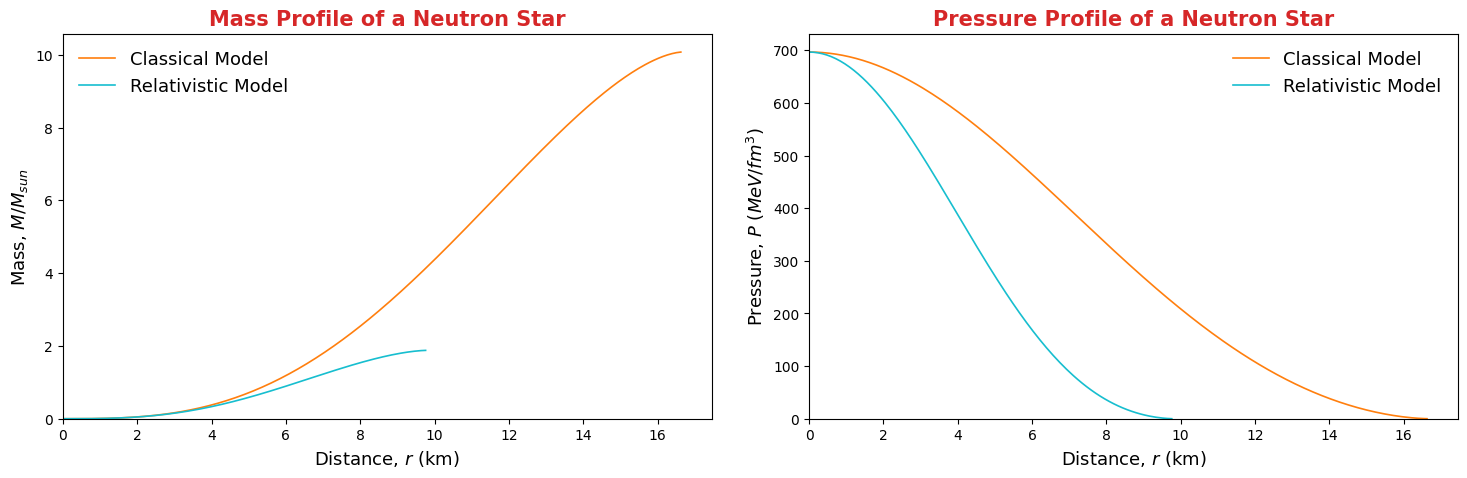

In [ ]:
plt.figure(figsize = (18, 5))                                   # setting up the figure size for subplots
for k in range(0,2):                                            # k will take two values in this run --> 0 and 1
    flag = flag_set[k]                                          # flag_set[0] = 0, flag_set[1] = 1
    for i in range(0,N-1):                                      # for 1500 iterations
        if flag == 0:                                           # if the flag is set to 0
            [m[i+1], p[i+1]] = RK4Solver(r[i],m[i],p[i],h,flag) # use classical model
        else:                                                   # if not 0
            [m[i+1], p[i+1]] = RK4Solver(r[i],m[i],p[i],h,flag) # use relativistic model
        if p[i+1] < tol:                                        # if the value of the pressure goes below tolerance (close to 0 as we know)
            break                                               # the simulation is completed
    print()                                                     # for a new line between outputs
    if i == N-2:                                                # if the pressure value was not able to go below the tolerance value
        lbl1 = "Program didn't converge to P = 0, extend the maximum value of r" # print to increase the itetarations of simulation that is the values of r
    else:                                                       # if simulation stopped before this
        lbl1 = f"P < {tol} found after {i} runs"                # print the conclusion statement


    m = m[:i+2]
    p = p[:i+2]
    r = r[:i+2]

    if flag == 0:
        lbl = "Classical Model"
        plot_data('tab:orange', "Classical Model")
    else:
        lbl = "Relativistic Model"
        plot_data('tab:cyan', "Relativistic Model")

    print (lbl, "Results:", lbl1)
    print ("Initial density, rho_s = ", rho_s, "MeV/fm^3")
    print ("Total mass = ", m[-1]*M0/Ms, "times Solar mass")
    print ("Radius of the Neutron star = ", r[-1]*R0*1e-18, "km")

print()
plt.subplots_adjust(wspace = 0.15)

## Conclusion <a name = 'h7'><a>
- The values obtained for the mass and radius of the neutron star using the relativistic model are consistent with what is expected for a neutron star.

- However, the values obtained using the classical model are not consistent with what is expected for a neutron star.

- Therefore, a non-relativistic model is not a good approximation for describing the properties of neutron stars, and a relativistic model is necessary to accurately predict the mass and other properties of neutron stars.